In [3]:
# Face Mask Dataset Load
import os
import glob
import pandas as pd

path = './Face Mask Dataset'

dataset = {
    'image_path': [],
    'mask_status': [],
    'where': []
}

for where in os.listdir(path):
    for status in os.listdir(os.path.join(path, where)):
        for image in glob.glob(os.path.join(path, where, status, '*.png')):
            dataset['image_path'].append(image)
            dataset['mask_status'].append(status)
            dataset['where'].append(where)

dataset = pd.DataFrame(dataset)
dataset.head()

,image_path,mask_status,where
0,./Face Mask Dataset/Test/WithMask/1361.png,WithMask,Test
1,./Face Mask Dataset/Test/WithMask/1413.png,WithMask,Test
2,./Face Mask Dataset/Test/WithMask/1405.png,WithMask,Test
3,./Face Mask Dataset/Test/WithMask/1389.png,WithMask,Test
4,./Face Mask Dataset/Test/WithMask/1388.png,WithMask,Test


mask_status
WithoutMask    5909
WithMask       5883
Name: count, dtype: int64


<Axes: xlabel='mask_status', ylabel='count'>

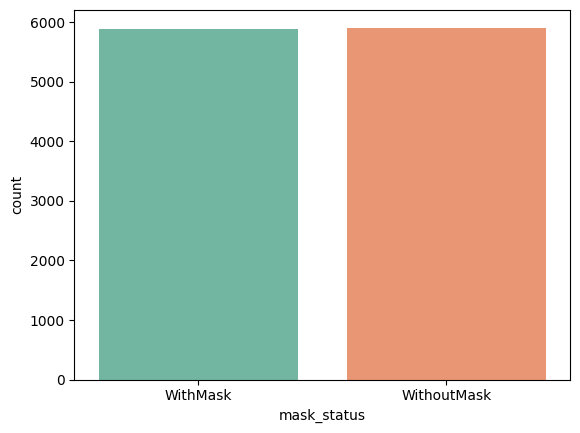

In [4]:
# 데이터 수 확인
import seaborn as sns

print(dataset.value_counts('mask_status'))
sns.countplot(x=dataset['mask_status'],
              hue=dataset['mask_status'],
              palette='Set2')

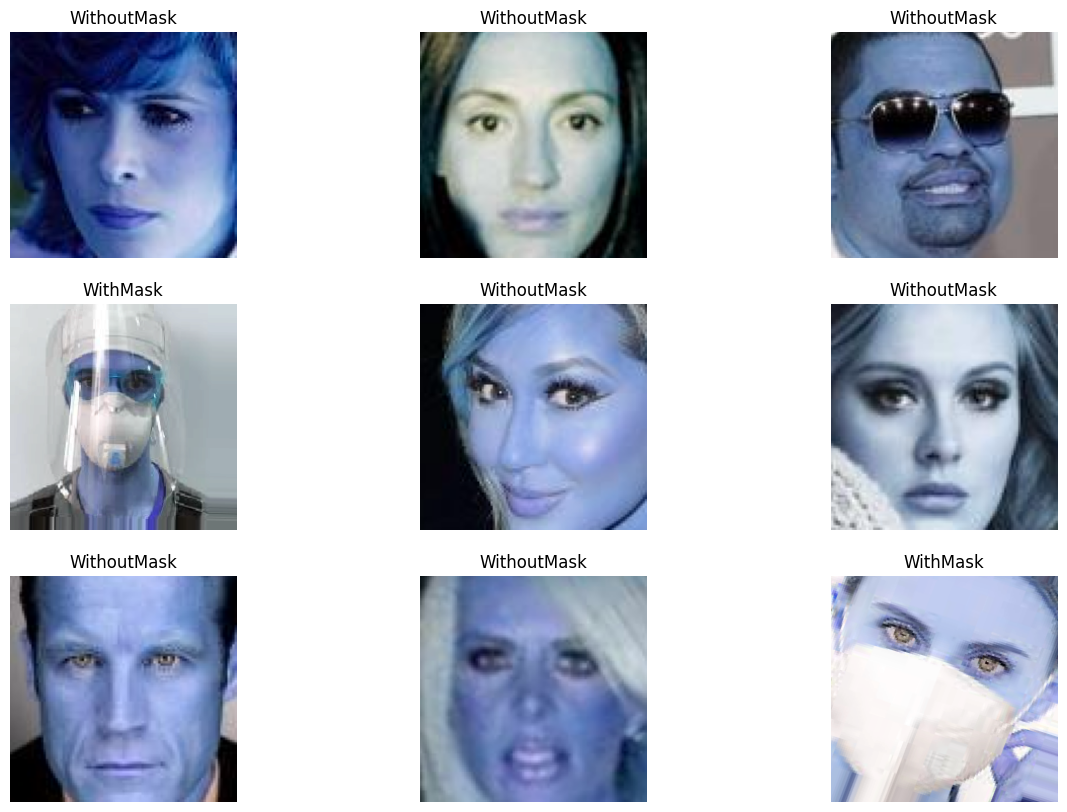

In [5]:
# 데이터 확인
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

for i in range(9):
    random = np.random.randint(0, len(dataset))

    plt.subplot(3, 3, i + 1)
    plt.imshow(cv2.imread(dataset['image_path'][random]))
    plt.title(dataset['mask_status'][random])
    plt.axis('off')
plt.show()

In [6]:
train_df = dataset[dataset['where'] == 'Train']
test_df = dataset[dataset['where'] == 'Test']
valid_df = dataset[dataset['where'] == 'Validation']

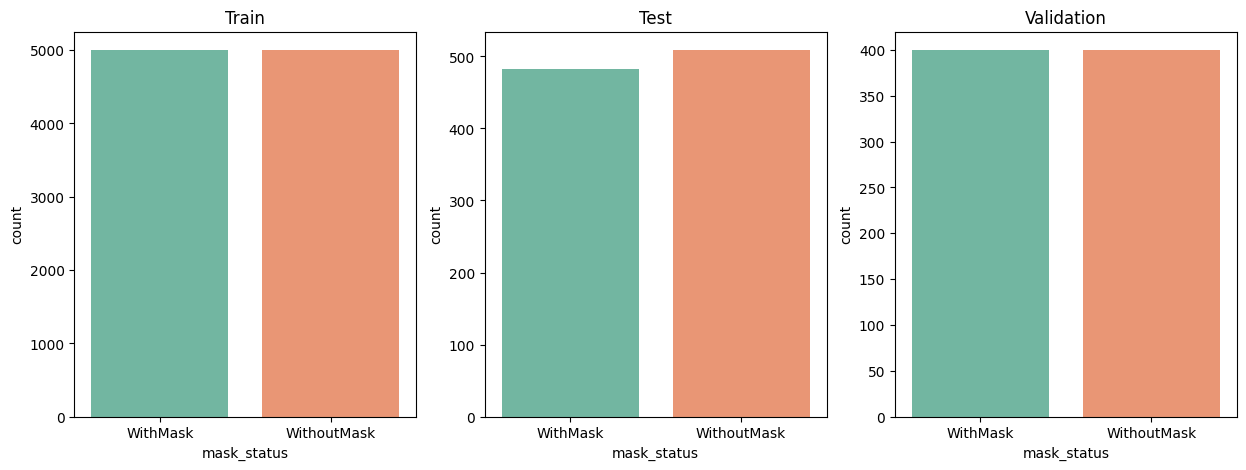

In [7]:
# Train, Test, Validation Data 수 확인
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.countplot(x=train_df['mask_status'],
              hue=train_df['mask_status'],
              palette='Set2')
plt.title('Train')

plt.subplot(1, 3, 2)
sns.countplot(x=test_df['mask_status'],
              hue=test_df['mask_status'],
              palette='Set2')
plt.title('Test')

plt.subplot(1, 3, 3)
sns.countplot(x=valid_df['mask_status'],
              hue=valid_df['mask_status'],
              palette='Set2')
plt.title('Validation')

plt.show()

In [8]:
train_df = train_df.reset_index(drop=True)
train_df.head()

,image_path,mask_status,where
0,./Face Mask Dataset/Train/WithMask/Augmented_7...,WithMask,Train
1,./Face Mask Dataset/Train/WithMask/Augmented_7...,WithMask,Train
2,./Face Mask Dataset/Train/WithMask/Augmented_7...,WithMask,Train
3,./Face Mask Dataset/Train/WithMask/Augmented_7...,WithMask,Train
4,./Face Mask Dataset/Train/WithMask/Augmented_7...,WithMask,Train


In [10]:
# 흑백변환 후 image resize
from PIL import Image
import numpy as np
from tqdm import tqdm

image_size = 50
paths = train_df['image_path'].tolist()
labels = train_df['mask_status'].tolist()

data = []
for path, label in tqdm(zip(paths, labels), total=len(paths)):
    with Image.open(path).convert('L') as img: # 흑백 이미지 변환
        img = img.resize((image_size, image_size)) # resize
        img_array = np.array(img)
        data.append([img_array, 1 if label == 'WithMask' else 0]) # 라벨링

100%|██████████| 10000/10000 [25:23<00:00,  6.56it/s]


In [15]:
# 데이터 섞기
np.random.shuffle(data)

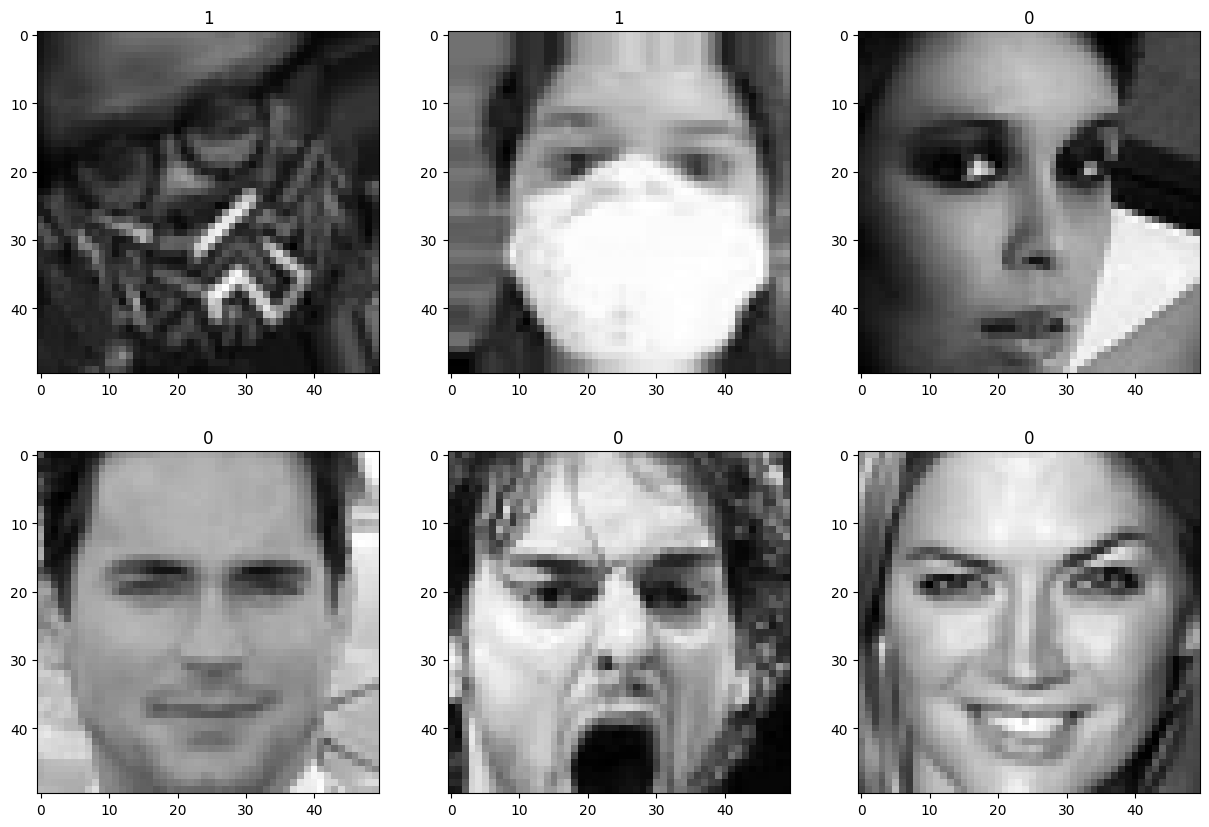

In [16]:
# 변환된 이미지 출력
# 크기를 50으로 줄여서 이미지가 흐려짐
fig, ax = plt.subplots(2, 3, figsize=(15, 10))

for row in range(2):
    for col in range(3):
        ax[row][col].imshow(data[row * 3 + col][0], cmap='gray')
        ax[row][col].set_title(data[row * 3 + col][1])
plt.show()

In [17]:
# 독립변수, 종속변수 나눠 저장
x = []
y = []

for image in data:
    x.append(image[0])
    y.append(image[1])

x = np.array(x)
y = np.array(y)

# 정규화
x = x / 255.0

In [18]:
# Data Split
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x,
                                                  y,
                                                  test_size=0.2,
                                                  random_state=13)

In [20]:
# Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout

model = Sequential([
    Conv2D(32,
           (5, 5),
           strides=(1, 1),
           padding='same',
           activation='relu',
           input_shape=(image_size, image_size, 1)),
    MaxPooling2D(pool_size=(2, 2),
                 strides=(2, 2)),
    Conv2D(64,
           (2, 2),
           padding='same',
           activation='relu'),
    MaxPooling2D(pool_size=(2, 2),
                 strides=(2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(1000,
          activation='relu'),
    Dense(1,
          activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1000)           │     9,217,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,227,089 (35.20 MB)

 Trainable params: 9,227,089 (35.20 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
x_train = x_train.reshape(len(x_train), image_size, image_size, 1)
x_val = x_val.reshape(len(x_val), image_size, image_size, 1)

hist = model.fit(x_train,
                 y_train,
                 epochs=5,
                 validation_data=(x_val, y_val))

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7586 - loss: 0.4887 - val_accuracy: 0.9605 - val_loss: 0.1007
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9619 - loss: 0.1094 - val_accuracy: 0.9735 - val_loss: 0.0711
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9697 - loss: 0.0904 - val_accuracy: 0.9790 - val_loss: 0.0625
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9790 - loss: 0.0614 - val_accuracy: 0.9730 - val_loss: 0.0651
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9777 - loss: 0.0550 - val_accuracy: 0.9785 - val_loss: 0.0686


In [22]:
# Evaluate
model.evaluate(x_val, y_val)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9811 - loss: 0.0602


[0.06857738643884659, 0.9785000085830688]

In [23]:
from sklearn.metrics import confusion_matrix, classification_report

pred = (model.predict(x_val) > 0.5).astype('int32')
print(classification_report(y_val, pred))
print(confusion_matrix(y_val, pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1005
           1       0.96      1.00      0.98       995

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000

[[965  40]
 [  3 992]]
